In [1]:
# =========================================================
# Create Table 1 for TAG
# =========================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. LOAD DATA
# =========================================================

# Read the dataset.
# Use a raw string so Windows backslashes are handled correctly.
df = pd.read_csv(r"E:\SDXC-Backup\Documents\UA PhD Program\AIM AHEAD\expanded_synrwd_master.csv")

# Total sample size for percentages
N = len(df)



In [2]:
# =========================================================
# 2. HELPER FUNCTIONS
# =========================================================

def summarize_continuous(series, label):
    """
    Return a one-row summary for a continuous variable using mean ± SD.
    Missing values are excluded automatically by pandas.
    """
    return {
        "Variable": label,
        "Summary": f"{series.mean():.1f} ± {series.std():.1f}"
    }

def summarize_binary(series, label, positive_value=1):
    """
    Return a one-row summary for a binary variable as n (%).
    Assumes the positive category is coded as 1 by default.
    """
    count = (series == positive_value).sum()
    pct = 100 * count / len(series)
    return {
        "Variable": label,
        "Summary": f"{count} ({pct:.1f}%)"
    }

def summarize_categorical(series, header_label):
    """
    Return multiple rows for a categorical variable:
    one header row plus one row per category level.
    """
    rows = [{"Variable": header_label, "Summary": ""}]
    counts = series.value_counts(dropna=False)

    for level, count in counts.items():
        pct = 100 * count / len(series)
        rows.append({
            "Variable": f"  {level}",
            "Summary": f"{count} ({pct:.1f}%)"
        })

    return rows

def collapse_race(value):
    """
    Collapse race values into broader, more interpretable categories.
    Edit this function after inspecting your actual race labels.
    """
    if pd.isna(value):
        return "Missing"

    v = str(value).strip().lower()

    # White
    if "white" in v:
        return "White"

    # Black / African American
    if "black" in v or "african american" in v:
        return "Black or African American"

    # Asian
    if "asian" in v:
        return "Asian"

    # American Indian / Alaska Native
    if "american indian" in v or "alaska native" in v:
        return "American Indian or Alaska Native"

    # Native Hawaiian / Pacific Islander
    if "hawaiian" in v or "pacific islander" in v:
        return "Native Hawaiian or Pacific Islander"

    # Multiracial / more than one race
    if "multiple" in v or "more than one" in v or "multiracial" in v:
        return "Multiracial"

    # Common ambiguous / unknown categories
    if "unknown" in v or "other" in v or "refused" in v or "unable" in v:
        return "Other / Unknown"

    return "Other / Unknown"



In [3]:
# =========================================================
# 3. CREATE ANALYSIS-FRIENDLY VARIABLES
# =========================================================

# Copy the data so we do not overwrite the original dataframe
df_table = df.copy()

# Collapse race categories into broader groups
if "race" in df_table.columns:
    df_table["race_collapsed"] = df_table["race"].apply(collapse_race)



In [4]:
# =========================================================
# 4. CHOOSE VARIABLES FOR TABLE 1
# =========================================================

# IMPORTANT:
# Table 1 should reflect your research question.
# Here we focus on demographics, outcome, and broad cohort descriptors
# rather than every possible comorbidity or risk factor.

rows = []

# -----------------------------
# Demographics
# -----------------------------
rows.append({"Variable": "Demographics", "Summary": ""})

if "age" in df_table.columns:
    rows.append(summarize_continuous(df_table["age"], "Age, mean ± SD"))

if "sex" in df_table.columns:
    rows.extend(summarize_categorical(df_table["sex"], "Sex"))

if "race_collapsed" in df_table.columns:
    rows.extend(summarize_categorical(df_table["race_collapsed"], "Race"))

if "race_ethnicity" in df_table.columns:
    rows.extend(summarize_categorical(df_table["race_ethnicity"], "Ethnicity"))

# -----------------------------
# Outcome
# -----------------------------
rows.append({"Variable": "Outcome", "Summary": ""})

if "patient_death_indicator" in df_table.columns:
    rows.append(summarize_binary(df_table["patient_death_indicator"], "Recorded mortality"))

# -----------------------------
# Optional clinical burden section
# Include only if your team wants a broad multimorbidity descriptor
# -----------------------------
comorbidity_vars = [
    "HYPERTENSION_indicator",
    "DIABETESUNCOMPLICATED_indicator",
    "DIABETESCOMPLICATED_indicator",
    "CHRONICLUNGDISEASE_indicator",
    "KIDNEYDISEASE_indicator",
    "DEPRESSION_indicator"
]

available_comorbidities = [c for c in comorbidity_vars if c in df_table.columns]

if available_comorbidities:
    # Create a simple comorbidity count as a broad cohort descriptor.
    # This is more aligned with your phenotype question than listing smoking/obesity by default.
    df_table["comorbidity_count"] = df_table[available_comorbidities].fillna(0).sum(axis=1)

    rows.append({"Variable": "Clinical burden", "Summary": ""})
    rows.append(summarize_continuous(df_table["comorbidity_count"], "Comorbidity count, mean ± SD"))



In [5]:
# =========================================================
# 5. BUILD THE TABLE 1 DATAFRAME
# =========================================================

table1 = pd.DataFrame(rows, columns=["Variable", "Summary"])

print(table1)

# Save a CSV version for easy editing in Excel or Word later
table1.to_csv("Table1_cohort_summary_revised.csv", index=False)



                                             Variable         Summary
0                                        Demographics                
1                                      Age, mean ± SD     45.8 ± 22.3
2                                                 Sex                
3                                              FEMALE  232071 (52.0%)
4                                                MALE  213978 (48.0%)
5                                 No matching concept       95 (0.0%)
6                                                Race                
7                                               White  262938 (58.9%)
8                                     Other / Unknown  110406 (24.7%)
9                                               Asian    40345 (9.0%)
10                          Black or African American    32448 (7.3%)
11                   American Indian or Alaska Native        6 (0.0%)
12                Native Hawaiian or Pacific Islander        1 (0.0%)
13                  

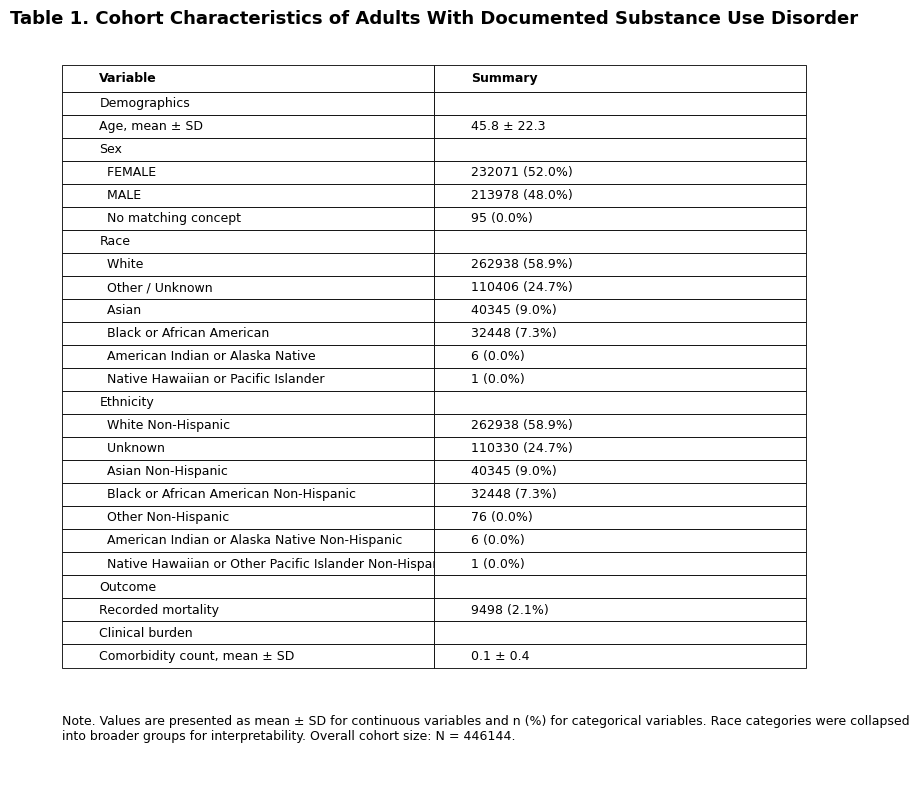

In [11]:
# =========================================================
# 6. RENDER TABLE 1
# =========================================================

# Make figure height depend on table size, but keep it compact
n_rows = len(table1) + 1   # +1 for header
fig_height = 0.33 * n_rows + 1.2

fig, ax = plt.subplots(figsize=(10, fig_height))
ax.axis("off")

title = "Table 1. Cohort Characteristics of Adults With Documented Substance Use Disorder"
ax.set_title(title, fontsize=13, fontweight="bold", pad=8)

# Put the table near the top and let it occupy most of the axes area
tbl = ax.table(
    cellText=table1.values,
    colLabels=table1.columns,
    cellLoc="left",
    colLoc="left",
    bbox=[0.02, 0.16, 0.96, 0.80]   # [left, bottom, width, height]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.15)

# Style header row
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_height(cell.get_height() * 1.15)
    cell.set_linewidth(0.6)

# Footnote placed directly under the table, inside the axes region
footnote = (
    "Note. Values are presented as mean ± SD for continuous variables and n (%) for categorical variables. "
    "Race categories were collapsed into broader groups for interpretability. "
    f"Overall cohort size: N = {N}."
)

ax.text(
    0.02, 0.06,
    footnote,
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=9,
    wrap=True
)

plt.savefig("Table1_cohort_summary_clean.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# =========================================================
# 7. EXPORT TABLE FOR SUBMISSION
# =========================================================

# Save the table as a CSV file for submission or formatting in Excel/Word
output_file = "AA_TAG_Table1_cohort_summary.csv"
table1.to_csv(output_file, index=False)

# Confirm successful export
print(f"\nTable 1 successfully saved as '{output_file}'")

# =========================================================
# 8. EXPORT FORMATTED TABLE (IMAGE)
# =========================================================

image_file = "AA_TAG_Table1_cohort_summary.png"

plt.savefig(image_file, dpi=300, bbox_inches="tight")

print(f"Formatted Table 1 saved as '{image_file}'")


# END SOLUTION


Table 1 successfully saved as 'AA_TAG_Table1_cohort_summary.csv'
Formatted Table 1 saved as 'AA_TAGTable1_cohort_summary.png'


<Figure size 640x480 with 0 Axes>